<a href="https://colab.research.google.com/github/mayukh-oss/Digital-Litracy/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# 📂 Import libraries
import pandas as pd
import numpy as np

print("📂 Uploading dataset...")

from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv('House_price_multifeatures.csv')

print("✅ Data loaded successfully!")
print(df.head())

📂 Uploading dataset...


Saving House_price_multifeatures.csv to House_price_multifeatures (2).csv
✅ Data loaded successfully!

📊 First 5 rows:
   Unnamed: 0                 Id  PropertyLocationStreet1  \
0           0  120210f35317ca697      503 LAKE LOUISE CIR   
1           0  12086db272d757be6             5934 NW 7 PL   
2           0  12057c35a22b0865c       5713 PALM RIVER RD   
3           0  12057cf31f8e69893  1805 MAGDALENE MANOR DR   
4           0  12057c5b7712cfb0b     7405 ALAFIA RIDGE LP   

  PropertyLocationStreet2 PropertyCity  CountyFIPS  PropertyZip  \
0                  19-201       NAPLES        21.0        34110   
1                     NaN        MIAMI        86.0        33127   
2                     NaN        TAMPA        57.0        33619   
3                     NaN        TAMPA        57.0        33613   
4                     NaN    RIVERVIEW        57.0        33569   

                   OwnerName        OwnerMailAddress1 OwnerMailAddress2  ...  \
0  BOLTZ, LARRY P & SANDRA A   

/tmp/ipykernel_36099/4128079996.py:11: DtypeWarning: Columns (12,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('House_price_multifeatures.csv')


In [12]:
print("\n🧹 Cleaning column names...")

df.columns = df.columns.str.strip().str.lower()

print("✅ Cleaned Columns:")
print(df.columns.tolist())


🧹 Cleaning column names...
✅ Cleaned Columns:
['unnamed: 0', 'id', 'propertylocationstreet1', 'propertylocationstreet2', 'propertycity', 'countyfips', 'propertyzip', 'ownername', 'ownermailaddress1', 'ownermailaddress2', 'ownercity', 'ownerstate', 'ownerzip', 'citizensterritory', 'constructiontype', 'numberofstories', 'numberoffamilies', 'yearbuilt', 'yearofroof', 'yearofroofverified', 'roofmaterial', 'adjsquarefeet', 'occupancy', 'numberofmonthsunoccupied', 'ppc', 'bceg', 'typeofresidence', 'floorofresidence', 'floridawindpool', 'distancetocoast', 'distancetosinkhole', 'distancetohydrant', 'distancetofiredepartment', 'firedistrict', 'respondingfiredepartment', 'centralstationalarm', 'automaticsprinklers', 'numberofclaims', 'locationwindspeed', 'designwindspeed', 'internalpressuredesign', 'windbornedebrisregion', 'terrain', 'roofdeckattachment', 'roofcover', 'rooftowallconnection', 'secondarywaterresistance', 'openingprotection', 'roofshape', 'designexposure', 'valueofhome', 'unattach

In [13]:
print("\n🧹 Dropping unnecessary columns...")

df = df.drop([
    'unnamed: 0',
    'id',
    'ownername',
    'ownermailaddress1',
    'ownermailaddress2',
    'geometry',
    'propertylocationstreet1',
    'propertylocationstreet2'
], axis=1, errors='ignore')

print("✅ Columns dropped!")


🧹 Dropping unnecessary columns...
✅ Columns dropped!


In [14]:
print("\n🎯 Setting target column...")

target_column = 'valueofhome'

if target_column not in df.columns:
    print("❌ Target column not found!")
else:
    print(f"✅ Target column: {target_column}")


🎯 Setting target column...
✅ Target column: valueofhome


In [15]:
print("\n🧹 Handling missing values...")

# Numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

print("✅ Missing values handled!")


🧹 Handling missing values...
✅ Missing values handled!


In [16]:
print("\n🔄 Encoding categorical variables...")

for col in cat_cols:
    if df[col].nunique() < 20:   # prevent RAM crash
        df = pd.get_dummies(df, columns=[col], drop_first=True)
    else:
        print(f"⚠️ Skipped: {col} (too many unique values)")

print("✅ Encoding completed!")


🔄 Encoding categorical variables...
⚠️ Skipped: propertycity (too many unique values)
⚠️ Skipped: ownercity (too many unique values)
⚠️ Skipped: ownerstate (too many unique values)
⚠️ Skipped: ownerzip (too many unique values)
⚠️ Skipped: ppc (too many unique values)
⚠️ Skipped: respondingfiredepartment (too many unique values)
⚠️ Skipped: unattachedstructure (too many unique values)
⚠️ Skipped: floodzone (too many unique values)
⚠️ Skipped: countyname (too many unique values)
⚠️ Skipped: sinkholeaddress (too many unique values)
⚠️ Skipped: lastsaledate (too many unique values)
⚠️ Skipped: floodzonelastupdateddate (too many unique values)
⚠️ Skipped: stateparcelid (too many unique values)
⚠️ Skipped: ttterritory (too many unique values)
✅ Encoding completed!


In [17]:
print("\n🔍 Final missing value check...")

if df.isnull().sum().sum() > 0:
    print("⚠️ Fixing remaining NaN...")
    df = df.fillna(0)

print("✅ Dataset is clean!")


🔍 Final missing value check...
⚠️ Fixing remaining NaN...
✅ Dataset is clean!


In [18]:
print("\n🎯 Splitting features and target...")

X = df.drop(target_column, axis=1)
y = df[target_column]

print("📐 Feature Shape:", X.shape)
print("📐 Target Shape:", y.shape)


🎯 Splitting features and target...
📐 Feature Shape: (81747, 133)
📐 Target Shape: (81747,)


In [19]:
from sklearn.model_selection import train_test_split

print("\n✂️ Splitting dataset...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Split completed!")
print("Training shape:", X_train.shape)


✂️ Splitting dataset...
✅ Split completed!
Training shape: (65397, 133)


In [21]:
print("\n📋 Data Types:")
print(X_train.dtypes)
print("\n🔄 Converting all data to numeric...")

X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

print("✅ Conversion done!")
print("\n🧹 Fixing NaN after conversion...")

# Remove non-numeric
X_train = X_train.select_dtypes(exclude=['object'])
X_test = X_test.select_dtypes(exclude=['object'])

# Final safety
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("✅ NaN fixed!")
from sklearn.linear_model import LinearRegression

print("\n🤖 Training Linear Regression Model...")

model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model training completed!")


📋 Data Types:
propertycity                            object
countyfips                             float64
propertyzip                              int64
ownercity                               object
ownerstate                              object
                                        ...   
improvementquality_MINIMUM/LOW COST       bool
improvementquality_SUPERIOR               bool
improvementquality_Unknown                bool
homestead_True                            bool
homestead_Unknown                         bool
Length: 133, dtype: object

🔄 Converting all data to numeric...
✅ Conversion done!

🧹 Fixing NaN after conversion...
✅ NaN fixed!

🤖 Training Linear Regression Model...
✅ Model training completed!


In [22]:
print("\n🔮 Making predictions...")

y_pred = model.predict(X_test)

print("✅ Predictions done!")

print("\n📊 Sample Predictions:")
for i in range(5):
    print(f"Actual: {y_test.iloc[i]} | Predicted: {y_pred[i]}")


🔮 Making predictions...
✅ Predictions done!

📊 Sample Predictions:
Actual: 269900.0 | Predicted: 354917.4671529159
Actual: 163285.0 | Predicted: 385778.10816121846
Actual: 165500.0 | Predicted: 156923.77199799567
Actual: 121539.0 | Predicted: 185620.9296424985
Actual: 160446.0 | Predicted: 133083.16860935092


In [25]:
from sklearn.metrics import mean_squared_error, r2_score

print("\n📏 Evaluating model...")

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("Accuracy:", r2)


📏 Evaluating model...
Mean Squared Error: 36111249517.66887
Root Mean Squared Error: 190029.60168791827
Accuracy: 0.4025133869954549



📊 Plotting Bar Graph (Sample Comparison)...


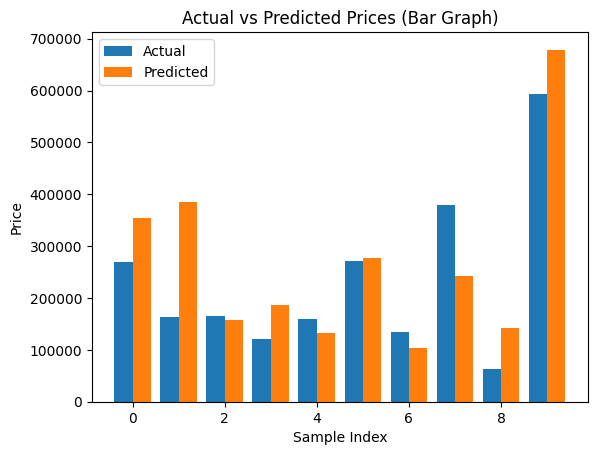

✅ Bar graph plotted!


In [26]:
import matplotlib.pyplot as plt

print("\n📊 Plotting Bar Graph (Sample Comparison)...")

# Take first 10 values
sample_size = 10
actual = y_test.iloc[:sample_size]
predicted = y_pred[:sample_size]

x = np.arange(sample_size)

plt.figure()
plt.bar(x - 0.2, actual, width=0.4, label='Actual')
plt.bar(x + 0.2, predicted, width=0.4, label='Predicted')

plt.xlabel("Sample Index")
plt.ylabel("Price")
plt.title("Actual vs Predicted Prices (Bar Graph)")
plt.legend()

plt.show()

print("✅ Bar graph plotted!")